# Coaxial Line with a Dielectric Window

TEM ports on a stepped coaxial line, validated against CST Studio Suite.

```
Import CAD  ->  FOM sweep  ->  POD  ->  ROM sweep  ->  compare S and Z with CST
```

## Why this model

A *uniform* transmission line is a weak test of a TEM port. It has no reflection, so
$|S_{11}| = 0$ and $|S_{21}| = 1$ almost regardless of what the port basis does, and an error
in the port normalisation hides inside a common phase.

This model is deliberately non-uniform. Over its $150$ mm length it carries

* a **centre-conductor step** -- radius $10 \to 20 \to 10$ mm inside a $50$ mm outer
  conductor, and
* a **ceramic window**, $\varepsilon_r = 10$, filling the outer annulus over a $10$ mm length.

Both produce real, frequency-dependent reflection, so the computed $S$ and $Z$ depend on the
port modes and their normalisation rather than on a bare propagation phase. The flat circular
faces at either end are coaxial **TEM ports**.

The same structure was solved in CST Studio Suite, and its exported $S$- and $Z$-matrices ship
with these docs, so every quantity below can be checked against an independent solver.

## 1. Import the geometry

In [1]:
from cavsim3d.core.em_project import EMProject
from cavsim3d.analytical.cst_result import CSTResult
import numpy as np
import matplotlib.pyplot as plt
import time
%matplotlib widget

proj = EMProject(name='tem_2port_line', base_dir='./simulations', overwrite=True)

geo = proj.import_geometry('../example_models/tem_2port_line.step',
                           unit='mm', auto_build=False)

# The STEP file carries three named solids: the air region, the ceramic window
# and the stepped centre conductor.
geo.set_materials({
    'solid1': {'eps_r': 1},    # air
    'solid2': {'eps_r': 10},   # ceramic window
    'solid5': 'PEC',           # centre conductor
})

geo.build()
geo.generate_mesh(maxh=0.01, curvaturesafety=1.5)   # maxh in metres: 10 mm

print(f'mesh: {geo.mesh.ne} elements')

✅ Creating new project 'tem_2port_line' at simulations\tem_2port_line



STEP solids found:
  - solid1
  - solid2
  - solid5

Ports found: 2

Material properties assigned: 2 dielectric, 1 PEC
Named 4 solids (3 unique materials):
  solid 0: 'solid1'
  solid 1: 'solid5'
  solid 2: 'solid1'
  solid 3: 'solid2'
Ports matched: 2/2
  port1                center=(0.00000, 0.15000, 0.00000)  normal=(-0.0000, 1.0000, 0.0000)
  port2                center=(0.00000, 0.00000, 0.00000)  normal=(0.0000, -1.0000, 0.0000)
Subtracting 1 PEC solid(s): ['solid5']


mesh: 4601 elements


In [2]:
geo.show('geometry')

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'ngsolve_version': 'Netgen x.x', 'mesh_dim': …

The permittivity distribution is worth a look before solving -- the window is the only
inhomogeneity in the model, and it is what puts structure into $S_{11}$.

In [3]:
proj.fds.draw_material_cf('eps')


Structure Topology
  Type: Single structure
  Domains (2): ['solid1', 'solid2']
  Ports (2): ['port1', 'port2']
  Mesh elements: 4601


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

## 2. Full-order sweep

One TEM mode per port is enough: a coaxial line carries no other propagating mode until well
above the top of this band.

In [4]:
fom_config = {
    'nportmodes': 1,
    'order': 3,
    'nsamples': 20,
    'fmin': 0.1,
    'fmax': 5.0,
    'solver_type': 'iterative',
    'iterative_opts': {'precond': 'bddc', 'maxsteps': 500, 'printrates': False},
    'verbose': False,
    'rerun': True,
}

t0 = time.time()
proj.fds.solve(config=fom_config)
t_fom = time.time() - t0
print(f'full-order sweep ({fom_config["nsamples"]} points): {t_fom:.1f} s')

Assembling Matrices...


Solving port eigenmodes...


Calculating Port Eigenmodes...


	port1 mode 0: TEM_00, kc=0.0000, sigma=+1
	port2 mode 0: TEM_00, kc=0.0000, sigma=+1
Port eigenmodes complete: 2 total modes


Saved port modes to simulations\tem_2port_line\fds\port_modes\port_modes.pkl

FDS Solve: 0.1000 - 5.0000 GHz, 20 samples


Global Coupled Solve


  
Coupled solve complete: 2 external ports in 98.74s (total iteration steps: 6937)


Saved port modes to simulations\tem_2port_line\fds\port_modes\port_modes.pkl


full-order sweep (20 points): 99.7 s


Both ports are detected as coaxial, and the dominant mode on each is TEM ($k_c = 0$).

In [5]:
proj.fds.print_port_info()


Port Information

Port: port1 [EXTERNAL (input)]
  Adjacent domains: ['solid1']
  Normal: [0. 1. 0.]
  Orientation factor: 1.0
  Mode 0: fc = 0.0000 GHz

Port: port2 [EXTERNAL (output)]
  Adjacent domains: ['solid1']
  Normal: [ 0. -1.  0.]
  Orientation factor: 1.0
  Mode 0: fc = 0.0000 GHz


In [6]:
proj.fds.plot_port_mode('port1')


Port Mode: port1 [external (input)], Mode 0
Cutoff frequency: 0.0000 GHz


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

## 3. What $S$ and $Z$ are referenced to

A TEM port admits **two** different impedances, and they are not interchangeable:

* the **wave impedance** $Z_\mathrm{TEM} = \eta = \sqrt{\mu/\varepsilon}$, a property of the
  medium, which for air is $376.73\ \Omega$ whatever the conductor radii are; and
* the **line impedance** $Z_0 = \dfrac{\eta}{2\pi}\ln(b/a)$, a property of the *geometry*,
  which follows from the unique voltage and current a TEM mode possesses.

Because a TEM mode has a well-defined $V$ and $I$, the line impedance is the physically
meaningful reference, and it is the one CST reports and normalises to. The code follows the
same convention by default. TE and TM modes have no unique voltage or current, so no line
impedance exists for them and both codes fall back to the wave impedance.

The choice is exposed as `impedance_reference`: `'line'` (the default, CST-compatible) or
`'wave'`.

In [7]:
ps = proj.fds.port_solver
f0 = 2.55e9   # the frequency at which CST exported its port information

cst_dir = '../example_models/cst_reference/tem_2port_line'
cst_line = {p: np.loadtxt(f'{cst_dir}/Export/Port Information_Line Impedance_{i}(1).txt')[1]
            for i, p in enumerate(proj.fds.ports, start=1)}
cst_wave = {p: np.loadtxt(f'{cst_dir}/Export/Port Information_Wave Impedance_{i}(1).txt')[1]
            for i, p in enumerate(proj.fds.ports, start=1)}

hdr = ('port', 'line Z0', 'CST line', 'wave Z', 'CST wave', 'reference used')
print(f'{hdr[0]:6s}{hdr[1]:>12s}{hdr[2]:>12s}{hdr[3]:>12s}{hdr[4]:>12s}{hdr[5]:>18s}')
for p in proj.fds.ports:
    zl = ps.get_port_line_impedance(p, 0)
    zw = ps.get_port_wave_impedance(p, 0, f0)
    zr = ps.get_port_reference_impedance(p, 0, f0)
    print(f'{p:6s}{abs(zl):11.3f} {cst_line[p]:11.3f} {abs(zw):11.3f} '
          f'{cst_wave[p]:11.3f} {abs(zr):17.3f}')
print('\nall values in ohm')

port       line Z0    CST line      wave Z    CST wave    reference used
port1      96.492      95.835     376.730     376.730            96.492
port2      96.487      95.848     376.730     376.730            96.487

all values in ohm


The two references differ by a factor of roughly $3.9$ here, so referencing $Z$ to the wrong
one leaves the S-parameters looking correct while the Z-parameters sit at a constant offset.
That is not a coincidence: the bilinear map from $Z$ to $S$ is invariant under a common
rescaling of the impedance matrix and its reference,

$$ \mathbf{S}(a\mathbf{Z},\, a\mathbf{Z}_\mathrm{ref}) = \mathbf{S}(\mathbf{Z},\, \mathbf{Z}_\mathrm{ref}), $$

so $S$ cannot expose the mistake and only a direct $Z$ comparison can.

## 4. S-parameters against CST

Loaded CST S-parameters from: tem_2port_line
  Frequency range: 0.1000 - 5.0000 GHz (1001 points)
  Ports: 2, Modes per port: 1
  S-parameters loaded: 4
  Z-parameters loaded: 4


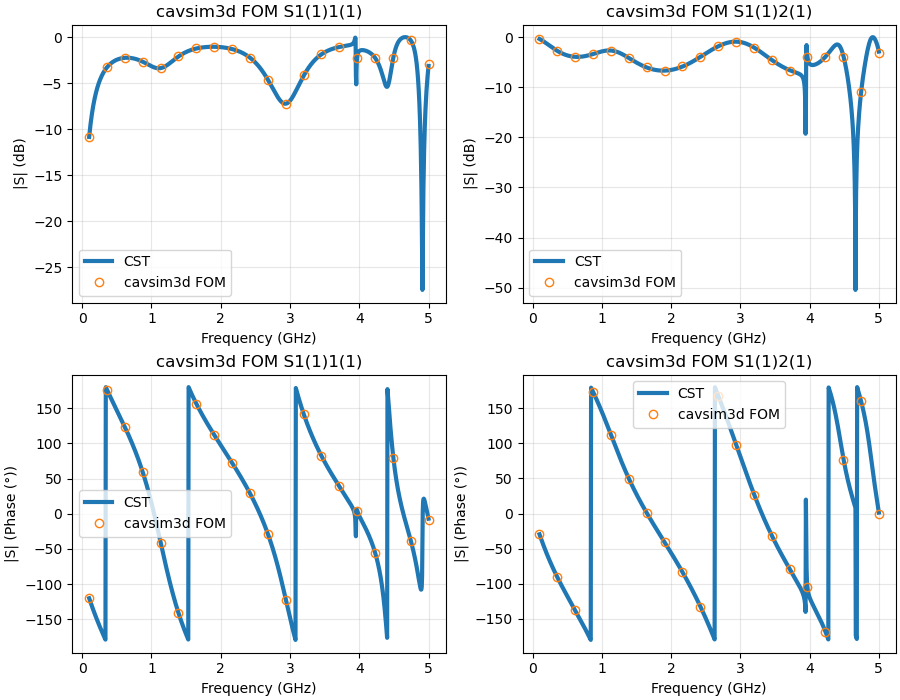

In [8]:
cst = CSTResult(cst_dir)

which = [['1(1)1(1)'], ['1(1)2(1)']]
fig, axs = plt.subplot_mosaic([[1, 2], [3, 4]], figsize=(9, 7), layout='constrained')
for idx, wh in enumerate(which):
    cst.plot_s(wh, ax=axs[idx + 1], lw=3, label='CST')
    proj.fds.fom.plot_s(wh, ax=axs[idx + 1], marker='o', lw=0, mfc='none', label='cavsim3d FOM')
    cst.plot_s(wh, plot_type='phase', ax=axs[idx + 3], lw=3, label='CST')
    proj.fds.fom.plot_s(wh, plot_type='phase', ax=axs[idx + 3],
                        marker='o', lw=0, mfc='none', label='cavsim3d FOM')
axs[1].legend()
plt.show()

## 5. Reduce

Twenty full-order snapshots are enough to build a reduced model, which can then be swept on an
arbitrarily fine grid at negligible cost.

In [9]:
rom = proj.fds.fom.reduce(tol=1e-15)

rom_config = {
    'nsamples': 1001,      # the same grid CST used
    'fmin': 0.1,
    'fmax': 5.0,
    'solver_type': 'direct',
    'rerun': True,
}

t0 = time.time()
rom.solve(config=rom_config)
t_rom = time.time() - t0
print(f'reduced sweep ({rom_config["nsamples"]} points): {t_rom:.3f} s')
print(f'cost per frequency point: FOM {t_fom / fom_config["nsamples"] * 1e3:.0f} ms'
      f'   ROM {t_rom / rom_config["nsamples"] * 1e3:.3f} ms')

Model Order Reduction


Reduction complete: 94914 -> 40 DOFs (100.0% compression)


Saved port modes to simulations\tem_2port_line\fds\port_modes\port_modes.pkl



ROM Solve: 0.1 - 5.0 GHz, 1001 samples


  Solve loop: 0.009s (1001 freq points)


Saved port modes to simulations\tem_2port_line\fds\port_modes\port_modes.pkl


reduced sweep (1001 points): 0.396 s
cost per frequency point: FOM 4986 ms   ROM 0.396 ms


## 6. FOM, ROM and CST together

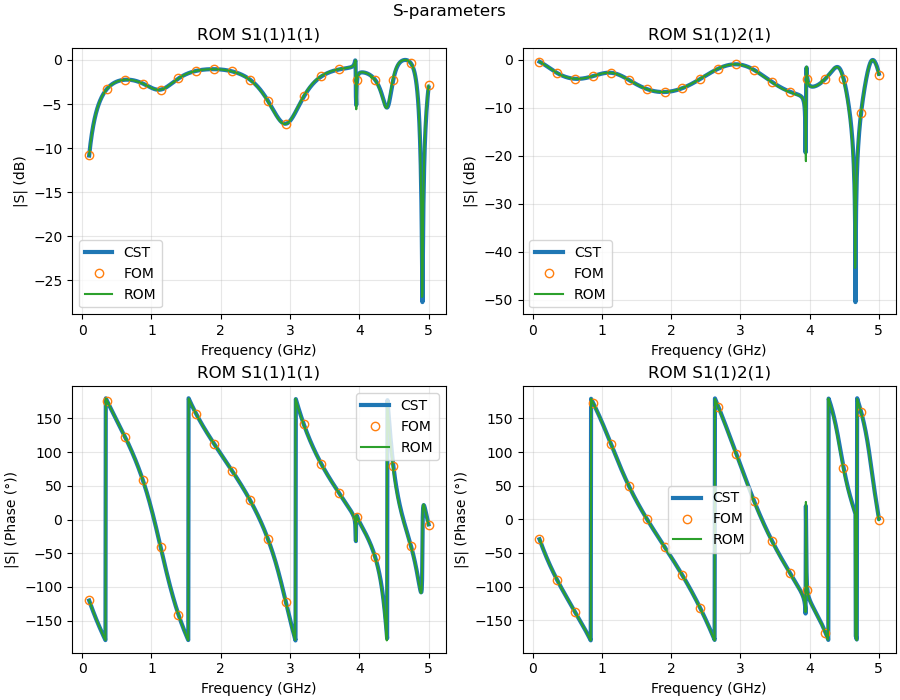

In [10]:
fig, axs = plt.subplot_mosaic([[1, 2], [3, 4]], figsize=(9, 7), layout='constrained')
for idx, wh in enumerate(which):
    cst.plot_s(wh, ax=axs[idx + 1], lw=3, label='CST')
    proj.fds.fom.plot_s(wh, ax=axs[idx + 1], marker='o', lw=0, mfc='none', label='FOM')
    rom.plot_s(wh, ax=axs[idx + 1], label='ROM')
    cst.plot_s(wh, plot_type='phase', ax=axs[idx + 3], lw=3, label='CST')
    proj.fds.fom.plot_s(wh, plot_type='phase', ax=axs[idx + 3],
                        marker='o', lw=0, mfc='none', label='FOM')
    rom.plot_s(wh, plot_type='phase', ax=axs[idx + 3], label='ROM')
axs[1].legend()
fig.suptitle('S-parameters')
plt.show()

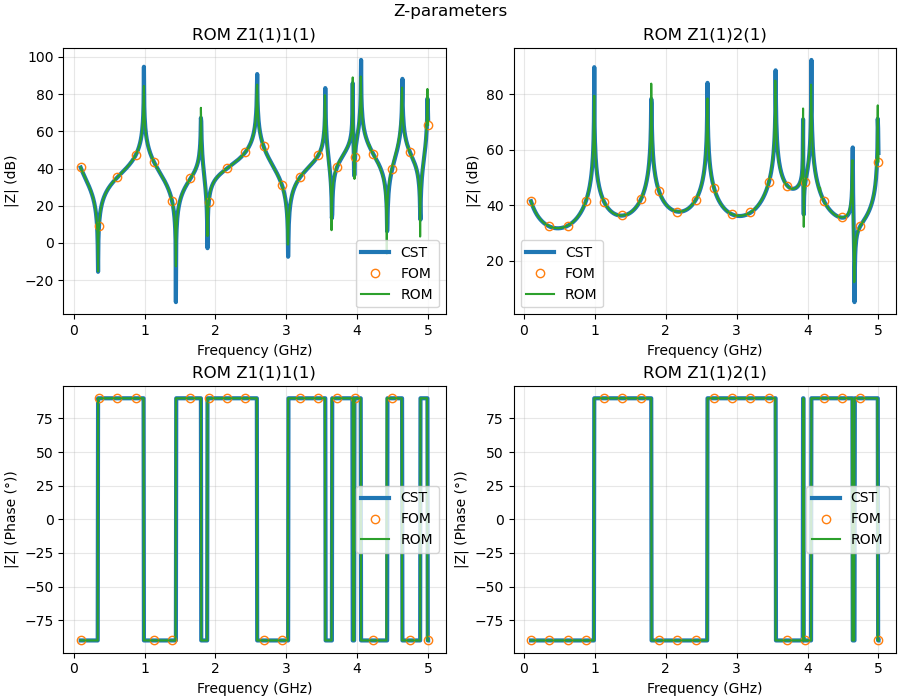

In [11]:
fig, axs = plt.subplot_mosaic([[1, 2], [3, 4]], figsize=(9, 7), layout='constrained')
for idx, wh in enumerate(which):
    cst.plot_z(wh, ax=axs[idx + 1], lw=3, label='CST')
    proj.fds.fom.plot_z(wh, ax=axs[idx + 1], marker='o', lw=0, mfc='none', label='FOM')
    rom.plot_z(wh, ax=axs[idx + 1], label='ROM')
    cst.plot_z(wh, plot_type='phase', ax=axs[idx + 3], lw=3, label='CST')
    proj.fds.fom.plot_z(wh, plot_type='phase', ax=axs[idx + 3],
                        marker='o', lw=0, mfc='none', label='FOM')
    rom.plot_z(wh, plot_type='phase', ax=axs[idx + 3], label='ROM')
axs[1].legend()
fig.suptitle('Z-parameters')
plt.show()

## 7. How close is it?

Both models are compared against CST on their own frequency grids, as the **median** pointwise
relative error in magnitude.

The median matters here. $S$ is bounded, but $Z$ has poles at the resonances of the structure,
where $|Z| \to \infty$; near one of them an arbitrarily small shift in the pole frequency
produces an arbitrarily large difference in $|Z|$. A mean relative error is dominated by those
few points and reports a large number even for two curves that lie on top of each other
everywhere else, so it measures pole placement rather than agreement. The median is insensitive
to them.

In [12]:
def median_rel_err(a, b):
    num, den = np.abs(np.abs(a) - np.abs(b)), np.abs(b)
    m = den > 1e-9
    return np.median(num[m] / den[m])


def compare(result, label):
    cst_i = cst.interpolate_to(result.frequencies)
    out = []
    for key, name in (('1(1)1(1)', 'S11'), ('1(1)2(1)', 'S21')):
        out.append((name, median_rel_err(result.S_dict[key], cst_i.S_dict[key])))
    for key, name in (('1(1)1(1)', 'Z11'), ('1(1)2(1)', 'Z21')):
        out.append((name, median_rel_err(result.Z_dict[key], cst_i.Z_dict[key])))
    print(f'{label:12s}' + ''.join(f'{e * 100:9.2f}%' for _, e in out))


print(f'{"":12s}' + ''.join(f'{n:>10s}' for n in ('S11', 'S21', 'Z11', 'Z21')))
compare(proj.fds.fom, 'full order')
compare(rom, 'reduced')

                   S11       S21       Z11       Z21
full order       0.22%     0.35%     1.96%     0.71%
reduced          0.18%     0.33%     2.13%     0.85%


## Summary

* A stepped coaxial line with a dielectric window gives TEM ports something to reflect from,
  which makes it a genuine test of the port basis rather than of a propagation phase.
* $S$ agrees with CST to a few tenths of a percent and $Z$ to about one to two percent
  (median), and the reduced model reproduces the full-order result while sweeping a
  $1001$-point grid in a small fraction of the time.
* $Z$ agrees only because it is referenced to the **line** impedance. That is the default;
  `impedance_reference = 'wave'` selects the alternative convention, under which $S$ is
  unchanged and $Z$ shifts by a constant factor per port.